Mô tả tập dữ liệu (Dataset Description)

- Tập dữ liệu bao gồm **dữ liệu theo giờ (hourly data)** với tổng cộng **310176** và **18 cột**.  
Khoảng thời gian bao phủ từ **00:00:00 ngày 1 tháng 1 năm 2022** đến **00:00:00 ngày 1 tháng 1 năm 2025**.  
Không có **giá trị bị thiếu** trong toàn bộ bảng dữ liệu.


Định nghĩa các cột (Column Definition)

**Nhóm chỉ số chất lượng không khí (Air Quality columns)**

| **Tên cột** | **Giải thích** | **Đơn vị** |
|--------------|----------------|-------------|
| **AQI** | Chỉ số chất lượng không khí tổng hợp (Air Quality Index) | – |
| **CO** | Nồng độ **Carbon Monoxide (CO)** – khí CO độc hại sinh ra từ đốt nhiên liệu | mg/m³ |
| **NO2** | Nồng độ **Nitrogen Dioxide (NO₂)** – khí độc gây kích ứng đường hô hấp | µg/m³ |
| **O3** | Nồng độ **Ozone (O₃)** – khí ozon tầng thấp có hại cho sức khỏe | µg/m³ |
| **PM10** | Nồng độ **bụi mịn PM10** – hạt bụi có đường kính ≤ 10 µm | µg/m³ |
| **PM25** | Nồng độ **bụi siêu mịn PM2.5** – hạt bụi có đường kính ≤ 2.5 µm | µg/m³ |
| **SO2** | Nồng độ **Sulfur Dioxide (SO₂)** – khí thải từ quá trình đốt than/dầu | µg/m³ |



**Nhóm yếu tố thời tiết (Weather columns)**

| **Tên cột** | **Giải thích** | **Đơn vị** |
|--------------|----------------|-------------|
| **Clouds** | Mức độ che phủ mây | % |
| **Precipitation** | Lượng mưa | mm |
| **Pressure** | Áp suất khí quyển | hPa |
| **Relative Humidity** | Độ ẩm tương đối | % |
| **Temperature** | Nhiệt độ không khí | °C |
| **UV Index** | Chỉ số tia cực tím (Ultraviolet Index) | – |
| **Wind Speed** | Tốc độ gió | m/s |



In [49]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [50]:
df = pd.read_csv('Data_Cleaned.csv')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310176 entries, 0 to 310175
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   District           310176 non-null  object 
 1   Local Time         310176 non-null  object 
 2   UTC Time           310176 non-null  object 
 3   City               310176 non-null  object 
 4   Country Code       310176 non-null  object 
 5   Timezone           310176 non-null  object 
 6   AQI                310176 non-null  int64  
 7   CO                 310176 non-null  float64
 8   NO2                310176 non-null  float64
 9   O3                 310176 non-null  float64
 10  PM25               310176 non-null  float64
 11  SO2                310176 non-null  float64
 12  Clouds             310176 non-null  float64
 13  Precipitation      310176 non-null  float64
 14  Pressure           310176 non-null  float64
 15  Relative Humidity  310176 non-null  float64
 16  Te

In [52]:
df.shape

(310176, 18)

In [53]:
df.describe()

,AQI,CO,NO2,O3,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
count,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000
mean,182.883782,1.870621,50.202709,33.058183,114.583910,40.674092,72.931719,0.216773,1011.021029,78.950254,24.276677,9.094815
std,87.701146,1.559461,25.439118,50.939325,97.995373,20.441111,38.046993,0.761341,7.289695,14.327225,5.499704,4.412542
min,0.000000,0.494000,12.340000,0.000000,12.500000,13.830000,0.000000,0.000000,997.500000,40.000000,10.700000,1.300000
25%,122.000000,0.895000,33.240000,0.100000,44.900000,26.460000,39.000000,0.000000,1005.000000,69.000000,20.600000,5.700000
50%,169.000000,1.295000,44.895000,8.310000,82.700000,35.290000,100.000000,0.000000,1010.600000,81.000000,25.200000,8.500000
75%,222.000000,2.163000,61.010000,45.780000,150.200000,49.110000,100.000000,0.100000,1016.500000,91.000000,28.100000,12.100000
max,500.000000,8.652000,152.170000,246.050000,494.000000,120.160000,100.000000,5.300000,1028.300000,99.000000,35.100000,21.400000


### 3.2. Chỉ số chất lượng không khí (AQI)

 3.2.1. AQI theo giờ của Hà Nội trong suốt cả năm

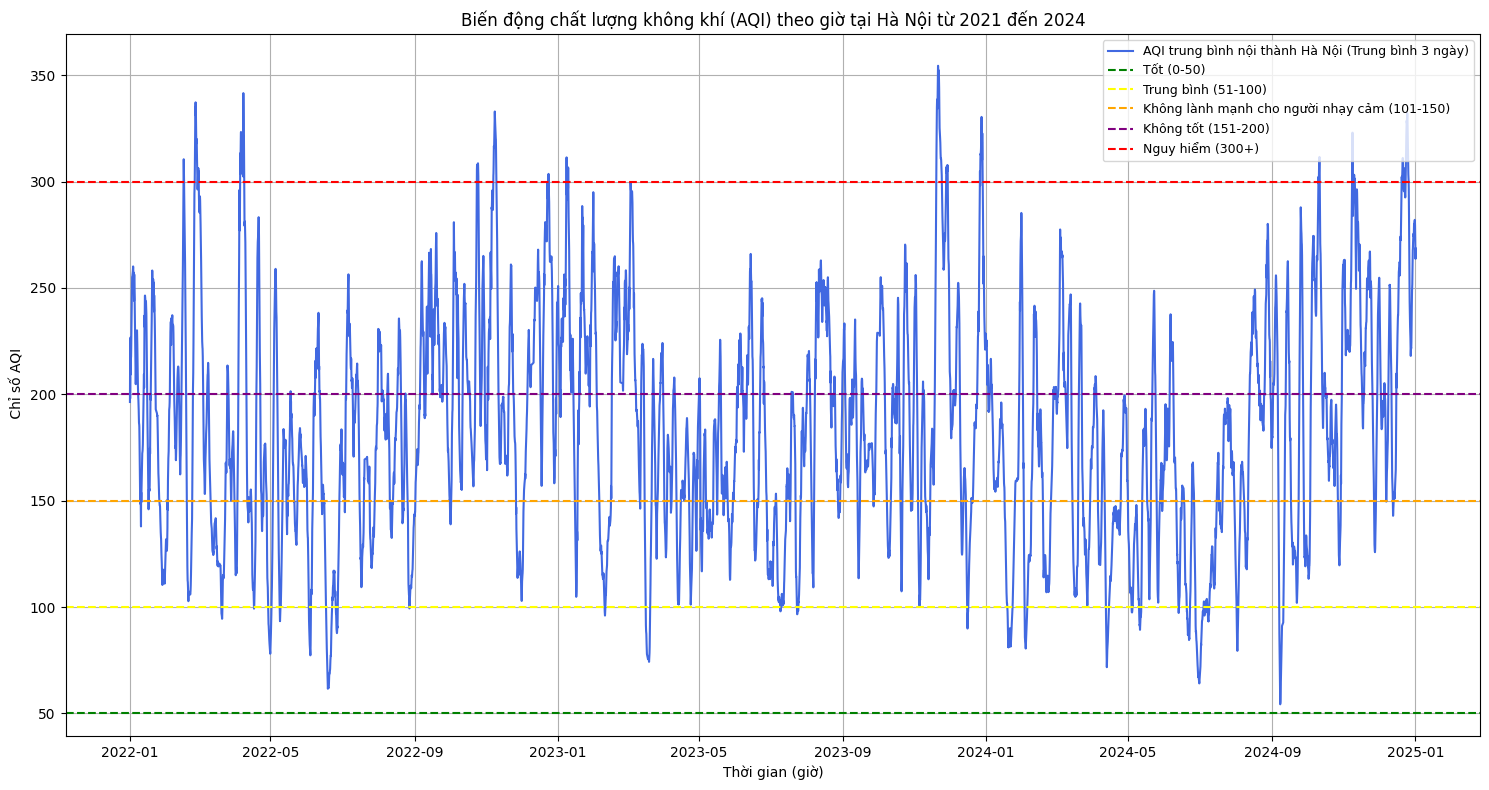

In [54]:

df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.dropna(subset=["Local Time"]).sort_values("Local Time")


df_mean = (
    df.groupby("Local Time", as_index=False)["AQI"].mean()
    .sort_values("Local Time")
)


df_mean["AQI_rolling"] = (
    df_mean["AQI"].rolling(window=24*3, center=True, min_periods=24).mean()
)
out = df_mean.dropna(subset=["AQI_rolling"])



plt.figure(figsize=(15,8))
plt.plot(out['Local Time'], out['AQI_rolling'], color='royalblue', linewidth=1.5, label='AQI trung bình nội thành Hà Nội (Trung bình 3 ngày)')
plt.axhline(50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(100, color='yellow', linestyle='--', label='Trung bình (51-100)')
plt.axhline(150, color='orange', linestyle='--', label='Không lành mạnh cho người nhạy cảm (101-150)')
plt.axhline(200, color='purple', linestyle='--', label='Không tốt (151-200)')
plt.axhline(300, color='red', linestyle='--', label='Nguy hiểm (300+)')
plt.title("Biến động chất lượng không khí (AQI) theo giờ tại Hà Nội từ 2021 đến 2024")
plt.xlabel("Thời gian (giờ)")
plt.ylabel(" Chỉ số AQI")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

3.2.2. AQI theo giờ của Hà Nội trong nhiều tháng với mức AQI nguy hiểm

In [55]:
df_city = (
    df.groupby("Local Time", as_index=False)['AQI'].mean().sort_values('Local Time')   
)

# Trung bình AQI theo giờ
df_city["Year"]  = df_city["Local Time"].dt.year
df_city["Month"] = df_city["Local Time"].dt.month

# Tìm các (Year, Month) có ÍT NHẤT một giờ AQI >= 300

monthly_haz = (
    df_city.assign(is_hazardous =(df_city['AQI'] >= 300).astype(int))
    .groupby(['Year', 'Month'])
    .agg(count_hazardous = ('is_hazardous', 'sum'), max_AQI = ('AQI', 'max'), mean_AQI = ('AQI', 'mean'))
    .reset_index()
)

top_months = monthly_haz.sort_values(['count_hazardous', 'max_AQI', 'mean_AQI'], ascending=False).head(3)
top_months


,Year,Month,count_hazardous,max_AQI,mean_AQI
22,2023,11,189,488.0,222.026389
34,2024,11,178,495.0,233.773611
12,2023,1,175,497.0,224.481183


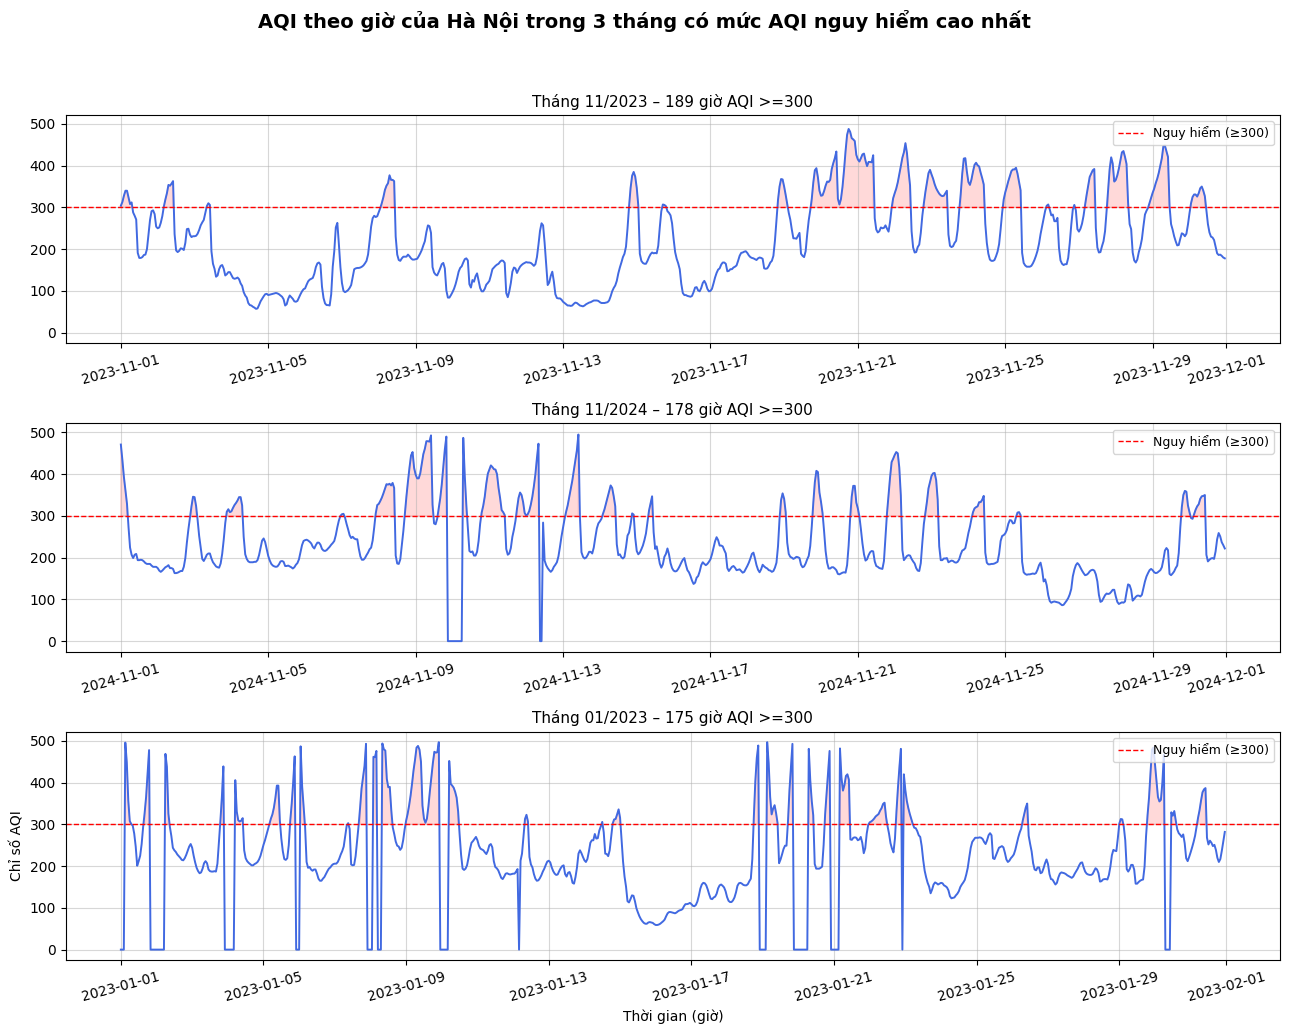

In [56]:
fig, axs = plt.subplots(len(top_months), 1, figsize=(13, 3.5*len(top_months)), sharey=True)

for ax, (_, row) in zip(axs, top_months.iterrows()):
    year, month = int(row["Year"]), int(row["Month"])
    sel = df_city[(df_city["Year"] == year) & (df_city["Month"] == month)]

    # Vẽ đường AQI
    ax.plot(sel["Local Time"], sel["AQI"], color="royalblue", lw=1.4)
    ax.axhline(300, color="red", ls="--", lw=1, label="Nguy hiểm (≥300)")
    
    # Tô màu vùng vượt ngưỡng
    ax.fill_between(sel["Local Time"], sel["AQI"], 300, where=sel["AQI"] >= 300, 
                    color="red", alpha=0.15)
    
    # Tiêu đề phụ từng subplot
    ax.set_title(f"Tháng {month:02d}/{year} – {int(row['count_hazardous'])} giờ AQI >=300", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.5)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle(f"AQI theo giờ của Hà Nội trong {len(top_months)} tháng có mức AQI nguy hiểm cao nhất", 
             fontsize=14, fontweight="bold")
plt.xlabel("Thời gian (giờ)")
plt.ylabel("Chỉ số AQI")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### 3.3. Pm2.5 Level

3.3.1. Hanoi hourly Pm2.5 level throughout the year

In [57]:
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.dropna(subset=["Local Time"]).sort_values("Local Time")


#2) PM2.5 trung bình toàn HN theo giờ (gộp 11 quận)
pmh = (df.groupby("Local Time", as_index=True)["PM25"]
         .mean()
         .sort_index())

pm_daily = pmh.resample('D').median()
pm_daily_roll = pm_daily.rolling(window=14, center=True, min_periods=7).mean()



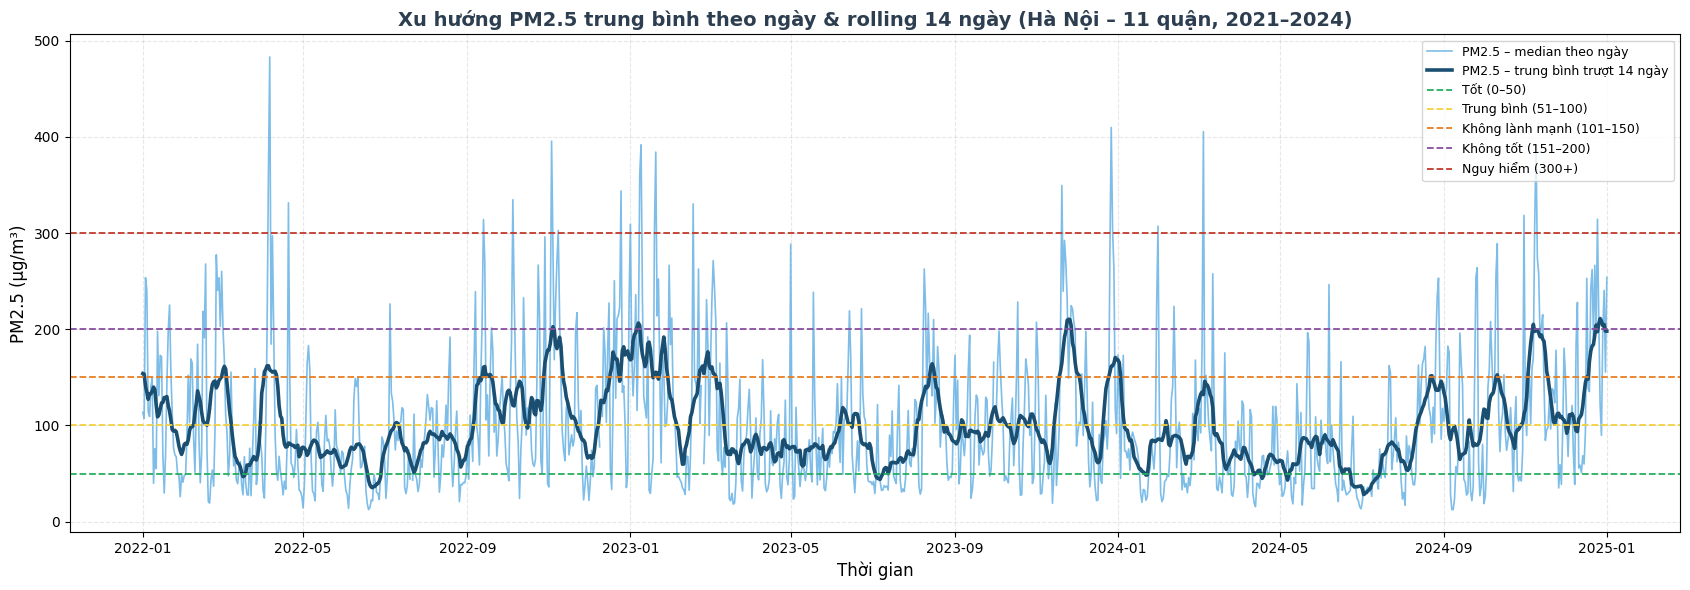

In [58]:
plt.figure(figsize=(17,6))

plt.plot(pm_daily.index, pm_daily, color='#5DADE2', lw=1.2, label='PM2.5 – median theo ngày', alpha=0.8)
         


plt.plot(pm_daily_roll.index, pm_daily_roll, color='#1B4F72', lw=2.6, label='PM2.5 – trung bình trượt 14 ngày')
         

plt.axhline(50,  color='#27AE60', ls='--', lw=1.3, label='Tốt (0–50)')
plt.axhline(100, color='#F4D03F', ls='--', lw=1.3, label='Trung bình (51–100)')
plt.axhline(150, color='#E67E22', ls='--', lw=1.3, label='Không lành mạnh (101–150)')
plt.axhline(200, color='#884EA0', ls='--', lw=1.3, label='Không tốt (151–200)')
plt.axhline(300, color='#C0392B', ls='--', lw=1.3, label='Nguy hiểm (300+)')

plt.title('Xu hướng PM2.5 trung bình theo ngày & rolling 14 ngày (Hà Nội – 11 quận, 2021–2024)', fontsize=14, fontweight='bold', color='#2C3E50')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('PM2.5 (μg/m³)', fontsize=12)
plt.legend(loc='upper right', fontsize=9, frameon=True, facecolor='white')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


🧩 Nhận xét chi tiết về biểu đồ

Biểu đồ: “Xu hướng PM2.5 trung bình theo ngày & rolling 14 ngày (Hà Nội – 11 quận, 2021–2024)”

📈 1️⃣ Xu hướng tổng thể

Nồng độ PM2.5 dao động rất mạnh theo thời gian, có nhiều đỉnh cao (spike) xuất hiện vào các giai đoạn mùa đông.

Đường trung bình trượt 14 ngày (màu xanh đậm) cho thấy xu hướng dao động theo chu kỳ hàng năm, tức là:

Mùa lạnh (tháng 11 – 3 năm sau): giá trị PM2.5 thường cao vượt ngưỡng 150 µg/m³, có thời điểm chạm gần 300 µg/m³.

Mùa hè (tháng 5 – 9): mức PM2.5 giảm mạnh, nhiều ngày nằm trong vùng “Tốt” hoặc “Trung bình” (0–100 µg/m³).

🌫 2️⃣ So sánh giữa các năm

Năm 2022, 2023 và 2024 đều có mô hình tương tự:
→ đỉnh ô nhiễm cao nhất xuất hiện vào cuối năm (tháng 11–12) và đầu năm sau (tháng 1–3).

Giữa năm 2023 và 2024, PM2.5 có xu hướng thấp hơn trung bình, thể hiện giai đoạn không khí tốt hơn (mùa mưa).

📉 3️⃣ Cường độ ô nhiễm

Dữ liệu có nhiều thời điểm vượt ngưỡng “Không tốt” (151–200) và thậm chí “Nguy hiểm” (>300), đặc biệt là các tháng mùa đông khô lạnh.

Đường median (màu xanh nhạt) thể hiện các dao động ngắn hạn mạnh, nhưng đường rolling cho thấy mức nền ô nhiễm luôn duy trì quanh 100–150 µg/m³, tức là trên mức “Trung bình” của chuẩn US-EPA.

💡 Giải thích nguyên nhân có thể

Mùa đông – xuân (11 → 3):

Không khí lạnh, ít gió, độ ẩm thấp → chất ô nhiễm tích tụ, khó khuếch tán.

Gia tăng đốt than tổ ong, rơm rạ, phương tiện giao thông hoạt động nhiều.

Mùa hè – thu (5 → 9):

Có mưa nhiều, gió mạnh, giúp “rửa trôi” bụi mịn trong không khí → PM2.5 giảm rõ rệt.

🧭 Kết luận tổng quan

Chất lượng không khí Hà Nội dao động mạnh theo mùa, xấu nhất vào mùa đông, tốt nhất vào mùa hè.

Mức PM2.5 trung bình ngày thường xuyên vượt ngưỡng khuyến nghị của WHO (15 µg/m³), cho thấy ô nhiễm bụi mịn vẫn là vấn đề nghiêm trọng kéo dài.

Các biện pháp kiểm soát nguồn phát thải (đốt sinh hoạt, giao thông, xây dựng) cần được tăng cường vào giai đoạn cuối năm – đầu năm.



3.3.2. Những giờ có nồng độ PM2.5 cao nhất

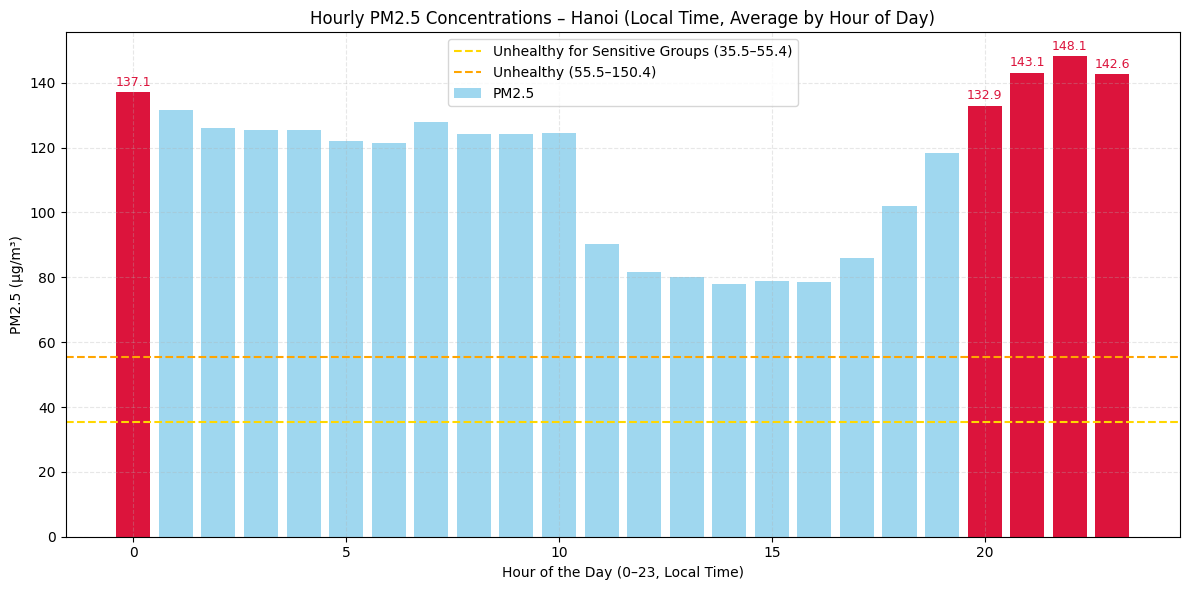

PM2.5 concentration at hour 22: 148.13
PM2.5 concentration at hour 21: 143.11
PM2.5 concentration at hour 23: 142.61
PM2.5 concentration at hour 0: 137.10
PM2.5 concentration at hour 20: 132.94


In [59]:
# Parse đúng cột 'Local Time' mà KHÔNG ép về UTC
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")

# Lấy giờ trong ngày (đã là giờ Việt Nam)
df["hour"] = df["Local Time"].dt.hour

# Tính trung bình PM2.5 theo giờ
pm_hourly = df.groupby("hour")["PM25"].mean()

# Xác định top 5 giờ có PM2.5 cao nhất
top_hours = pm_hourly.sort_values(ascending=False).head(5)

# Vẽ biểu đồ
plt.figure(figsize=(12,6))
plt.bar(pm_hourly.index, pm_hourly.values, color='skyblue', alpha=0.8, label='PM2.5')

# Tô đỏ giờ cao nhất
for h in top_hours.index:
    plt.bar(h, pm_hourly[h], color='crimson')
    plt.text(h, pm_hourly[h]+1, f"{pm_hourly[h]:.1f}", ha='center', va='bottom', color='crimson', fontsize=9)

# Thêm ngưỡng US EPA
plt.axhline(35.4, color='gold', ls='--', label='Unhealthy for Sensitive Groups (35.5–55.4)')
plt.axhline(55.4, color='orange', ls='--', label='Unhealthy (55.5–150.4)')

plt.title("Hourly PM2.5 Concentrations – Hanoi (Local Time, Average by Hour of Day)")
plt.xlabel("Hour of the Day (0–23, Local Time)")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# In top giờ cao nhất
for h, v in top_hours.items():
    print(f"PM2.5 concentration at hour {h}: {v:.2f}")

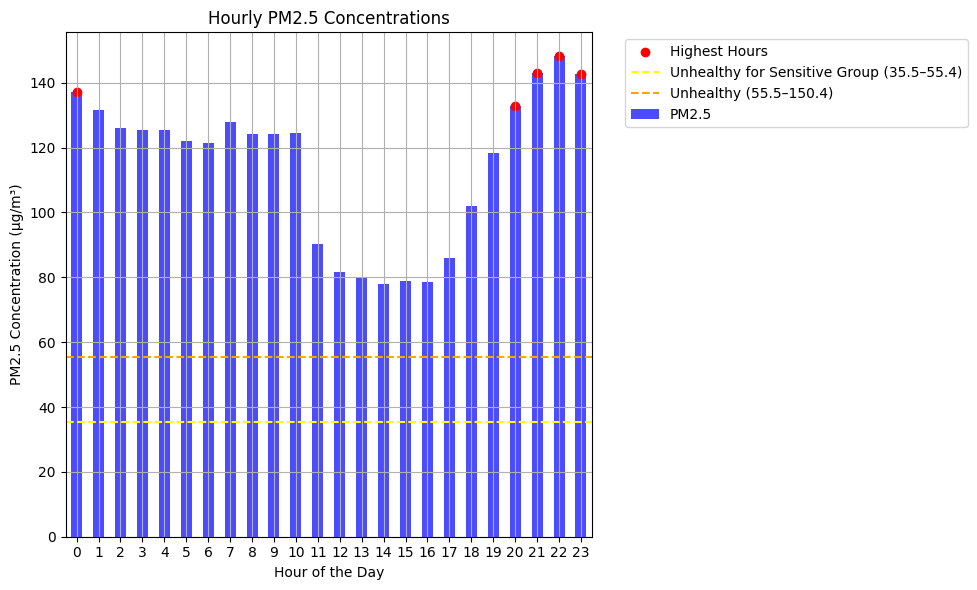

In [60]:
# --- Bước 1: tính trung bình PM2.5 toàn Hà Nội theo thời gian ---
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.dropna(subset=["Local Time"]).sort_values("Local Time")

pmh = (df.groupby("Local Time", as_index=True)["PM25"]
         .mean()
         .sort_index())

# --- Bước 2: group theo giờ trong ngày ---
hourly_pm25 = pmh.groupby(pmh.index.hour).mean()

# --- Bước 3: tìm các giờ có PM2.5 cao nhất ---
highest_hours = hourly_pm25.nlargest(5)

# --- Bước 4: vẽ biểu đồ ---
plt.figure(figsize=(10,6))
hourly_pm25.plot(kind='bar', color='blue', alpha=0.7, label='PM2.5')
plt.scatter(highest_hours.index, highest_hours.values, color='red', label='Highest Hours')

plt.title('Hourly PM2.5 Concentrations')
plt.xlabel('Hour of the Day')
plt.ylabel('PM2.5 Concentration (μg/m³)')
plt.axhline(y=35.5, color='yellow', linestyle='--', label='Unhealthy for Sensitive Group (35.5–55.4)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Unhealthy (55.5–150.4)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation='horizontal')
plt.tight_layout()
plt.show()
